# 🎯 YouTube Success Predictor - Multi-Output Deep Learning

## Objetivo
Predecir **views**, **likes** y **comments** de un video ANTES de subirlo, usando solo metadatos.

**Target**: `views`, `likes`, `comments`  
**Métrica de éxito**: `engagement = (likes + 50*comments) / views`

- **< 2%**: Pasable
- **3-7%**: Buena acogida
- **> 10%**: Éxito total

---

## 📦 1. Instalación de librerías

In [2]:
# Ejecutar solo si necesitas instalar
# !pip install tensorflow sentence-transformers scikit-learn pandas numpy matplotlib seaborn vaderSentiment joblib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Model  # ✅ Correcto
from tensorflow.keras.optimizers import Adam

# NLP
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


---
## 📊 2. Carga y Exploración de Datos

In [2]:
# Cargar dataset
df = pd.read_csv('dataset_ML_food.csv')

print(f"📁 Dataset shape: {df.shape}")
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())

df.head(3)

📁 Dataset shape: (6457, 24)

📋 Columnas disponibles:
['video_id', 'title', 'description', 'published_at', 'channel_id', 'channel_title', 'category_id', 'category_name', 'tags', 'tag_count', 'duration_sec', 'definition', 'caption', 'licensed_content', 'view_count', 'like_count', 'comment_count', 'default_audio_lang', 'music_info', 'url', 'subscriber_count', 'made_for_kids', 'views_per_hour', 'publish_day_of_week']


,video_id,title,description,published_at,channel_id,channel_title,category_id,category_name,tags,tag_count,...,view_count,like_count,comment_count,default_audio_lang,music_info,url,subscriber_count,made_for_kids,views_per_hour,publish_day_of_week
0,nOQIkDSqYsM,Dubai chocolate food #mukbang #food #crushingt...,NaN,2026-01-28T23:34:49Z,UCOA2GO5uirHX3QO9WYCJ11A,Dream Drift Story,28,Science & Technology,NaN,0,...,10811,105,0,en,None detected,https://www.youtube.com/shorts/nOQIkDSqYsM,19300,0,162.32,Wednesday
1,_akmQ3xZpds,One job challenge #foodreview #candy #mukbang ...,NaN,2026-01-28T23:33:54Z,UCOA2GO5uirHX3QO9WYCJ11A,Dream Drift Story,28,Science & Technology,NaN,0,...,10798,84,0,en,None detected,https://www.youtube.com/shorts/_akmQ3xZpds,19300,0,162.09,Wednesday
2,NRU4bVlGk3M,Trying 7 kinds of Asian ice creams… the mochi ...,Trying 7 kinds of Asian ice creams… the mochi ...,2026-01-28T23:28:58Z,UCV_bAXpZqUzZ6SYfOUfwe9w,Kim&Liz Too,24,Entertainment,Food|Eating|Mukbang|Ice cream|Mochi|Dessert,6,...,426510,15263,501,en-US,None detected,https://www.youtube.com/shorts/NRU4bVlGk3M,4450000,0,6394.32,Wednesday


In [3]:
# Información básica
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6457 entries, 0 to 6456
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   video_id             6457 non-null   str    
 1   title                6457 non-null   str    
 2   description          3398 non-null   str    
 3   published_at         6457 non-null   str    
 4   channel_id           6457 non-null   str    
 5   channel_title        6457 non-null   str    
 6   category_id          6457 non-null   int64  
 7   category_name        6457 non-null   str    
 8   tags                 1778 non-null   str    
 9   tag_count            6457 non-null   int64  
 10  duration_sec         6457 non-null   float64
 11  definition           6457 non-null   str    
 12  caption              6457 non-null   bool   
 13  licensed_content     6457 non-null   bool   
 14  view_count           6457 non-null   int64  
 15  like_count           6457 non-null   int64  
 16 

In [4]:
# Estadísticas de las variables target
print("📊 Estadísticas de TARGET VARIABLES:\n")
print(df[['view_count', 'like_count', 'comment_count']].describe())

📊 Estadísticas de TARGET VARIABLES:

         view_count     like_count  comment_count
count  6.457000e+03    6457.000000    6457.000000
mean   9.289428e+04     946.611429       8.479170
std    1.146539e+06   11058.823385      79.041087
min    0.000000e+00       0.000000       0.000000
25%    7.650000e+02       4.000000       0.000000
50%    1.568000e+03      17.000000       0.000000
75%    8.236000e+03      72.000000       2.000000
max    4.169162e+07  524721.000000    4725.000000


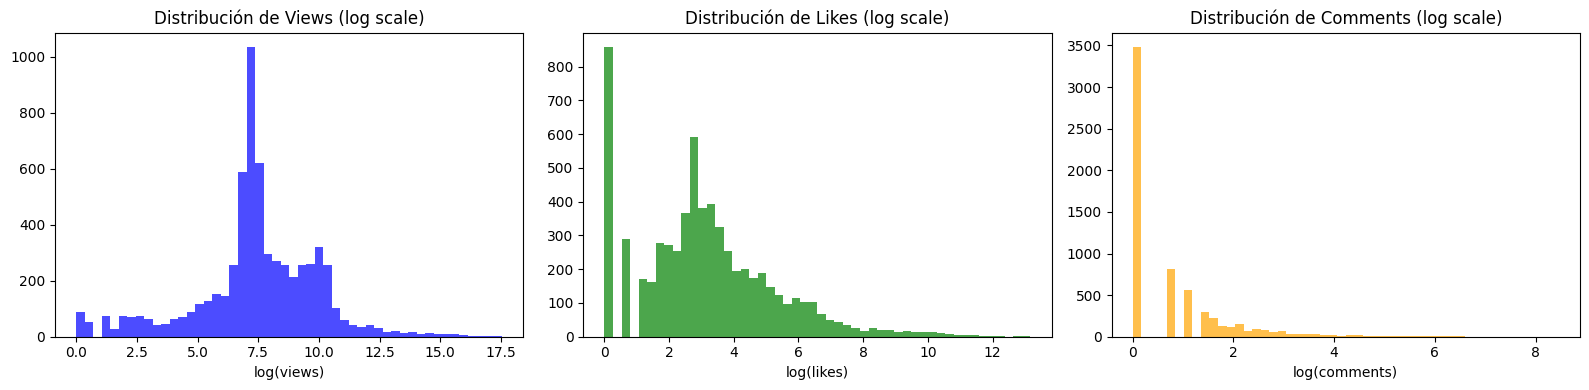

In [5]:
# Visualización distribución de targets
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Views
axes[0].hist(np.log1p(df['view_count']), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Distribución de Views (log scale)')
axes[0].set_xlabel('log(views)')

# Likes
axes[1].hist(np.log1p(df['like_count']), bins=50, color='green', alpha=0.7)
axes[1].set_title('Distribución de Likes (log scale)')
axes[1].set_xlabel('log(likes)')

# Comments
axes[2].hist(np.log1p(df['comment_count']), bins=50, color='orange', alpha=0.7)
axes[2].set_title('Distribución de Comments (log scale)')
axes[2].set_xlabel('log(comments)')

plt.tight_layout()
plt.show()

In [6]:
# Calcular engagement actual (para entender los datos)
df['actual_engagement'] = ((df['like_count'] + 50 * df['comment_count']) / df['view_count'] * 100).fillna(0)
df['actual_engagement'] = df['actual_engagement'].replace([np.inf, -np.inf], 0)

print("📈 Distribución de Engagement Actual:\n")
print(df['actual_engagement'].describe())

# Clasificar videos según engagement
def classify_engagement(eng):
    if eng < 2:
        return 'Pasable'
    elif eng <= 7:
        return 'Bueno'
    elif eng <= 10:
        return 'Muy Bueno'
    else:
        return 'Éxito Total'

df['engagement_class'] = df['actual_engagement'].apply(classify_engagement)
print("\n📊 Distribución de clases:\n")
print(df['engagement_class'].value_counts())

📈 Distribución de Engagement Actual:

count    6457.000000
mean       14.298807
std       113.303463
min         0.000000
25%         0.599355
50%         1.683502
75%         6.142831
max      5000.000000
Name: actual_engagement, dtype: float64

📊 Distribución de clases:

engagement_class
Pasable        3490
Bueno          1506
Éxito Total    1050
Muy Bueno       411
Name: count, dtype: int64


In [7]:
## aqui lo que haremos es hacer un repaso de todo el csv y si el engagement es mayor a 20%,quitaremos ese registro para entrenar al modelo.

## vemos que el max engagement es 5000%. Esto puede desvirtuar el modelo ( a lo mejor 100 views y 100 likes y 500 coments), asi que vamos a hacer algo para quitar videos problematicos

In [8]:
# Filtrar videos con engagement extremo (outliers)
print(f"📊 Registros ANTES de filtrar: {len(df)}")
print(f"   Max engagement: {df['actual_engagement'].max():.2f}%")
print(f"   Min engagement: {df['actual_engagement'].min():.2f}%")
print(f"   Videos con engagement > 25%: {(df['actual_engagement'] > 25).sum()}")
print(f"   Videos con engagement < 0.1%: {(df['actual_engagement'] < 0.1).sum()}")

# Quitar videos con engagement extremo (< 0.1% o > 25%)
df_clean = df[(df['actual_engagement'] >= 0.1) & (df['actual_engagement'] <= 25)].copy()

print(f"\n✅ Registros DESPUÉS de filtrar: {len(df_clean)}")
print(f"   Registros eliminados: {len(df) - len(df_clean)}")
print(f"   Rango de engagement: {df_clean['actual_engagement'].min():.2f}% - {df_clean['actual_engagement'].max():.2f}%")

# Usar el dataset limpio para el resto del análisis
df = df_clean

📊 Registros ANTES de filtrar: 6457
   Max engagement: 5000.00%
   Min engagement: 0.00%
   Videos con engagement > 25%: 388
   Videos con engagement < 0.1%: 695

✅ Registros DESPUÉS de filtrar: 5374
   Registros eliminados: 1083
   Rango de engagement: 0.10% - 25.00%


---
## 🛠️ 3. Feature Engineering

In [9]:
# Copiar dataframe para no modificar el original
data = df.copy()

# Rellenar valores nulos
data['title'] = data['title'].fillna('')
data['description'] = data['description'].fillna('')
data['tags'] = data['tags'].fillna('')
data['default_audio_lang'] = data['default_audio_lang'].fillna('unknown')
data['music_info'] = data['music_info'].fillna('')

### 3.1 Features Textuales: Calcular el sentimiento de un texto

In [10]:
# Análisis de sentimiento
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text or text.strip() == '':
        return 0.0
    return analyzer.polarity_scores(text)['compound']

data['title_sentiment'] = data['title'].apply(get_sentiment)
data['desc_sentiment'] = data['description'].apply(get_sentiment)

print("✅ Sentimientos calculados")

✅ Sentimientos calculados


In [11]:
# Features básicas de texto
import re

def count_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return len(emoji_pattern.findall(text))

def count_hashtags(text):
    return len(re.findall(r'#\w+', text))

def count_uppercase(text):
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)

# Aplicar
data['title_length'] = data['title'].str.len()
data['title_word_count'] = data['title'].str.split().str.len()
data['title_emoji_count'] = data['title'].apply(count_emojis)
data['title_hashtag_count'] = data['title'].apply(count_hashtags)
data['title_uppercase_ratio'] = data['title'].apply(count_uppercase)

data['desc_length'] = data['description'].str.len()
data['desc_word_count'] = data['description'].str.split().str.len()
data['desc_has_link'] = data['description'].str.contains('http', case=False, na=False).astype(int)

print("✅ Features textuales básicas creadas")

✅ Features textuales básicas creadas


In [12]:
# Embeddings de título usando Sentence-BERT
# genera representaciones vectoriales(numeros) de los títulos de los videos
print("🔄 Generando embeddings de títulos... (esto puede tardar un poco)")

model_embeddings = SentenceTransformer('all-MiniLM-L6-v2')  # Modelo ligero y rápido
title_embeddings = model_embeddings.encode(data['title'].tolist(), show_progress_bar=True)

print(f"✅ Embeddings generados: shape = {title_embeddings.shape}")

# Guardar embeddings
np.save('title_embeddings.npy', title_embeddings)

🔄 Generando embeddings de títulos... (esto puede tardar un poco)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 988.61it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 168/168 [00:11<00:00, 14.52it/s]


✅ Embeddings generados: shape = (5374, 384)


---

## ⚙️ ML DeepL Engine

Para crear el modelo, se ha tenido que:

### 1️⃣ Limpieza de datos (Outliers)
- Quitar registros que estuvieran muy fuera de rango del engagement
- Filtrar videos con engagement < 0.1% (sin interacción) o > 25% (valores extremos)
- Mantener solo datos realistas para el entrenamiento

---

### 2️⃣ Feature Engineering
**¿Qué es?** Crear nuevas características (features) a partir de los datos originales para que el modelo aprenda mejor.

Incluye varias técnicas:

**🔤 A) Vectorización de textos (Embeddings)**
- Convertir títulos de texto → números que el modelo entiende
- Usa Sentence-BERT (all-MiniLM-L6-v2) para capturar el significado semántico
- Cada título se convierte en un vector de 384 números
- Ejemplo: "Amazing Recipe 🔥" → [0.23, -0.15, 0.87, ..., 0.45]

**💬 B) Análisis de sentimiento**
- Analizar si el título/descripción es positivo, negativo o neutral (-1 a +1)
  - "Amazing Recipe! 🔥" → Sentimiento: +0.8 (muy positivo)
  - "Boring food" → Sentimiento: -0.3 (negativo)

**📝 C) Características de texto**
- Contar emojis en el título (más emojis = más llamativo)
- Contar hashtags (#foodie, #viral)
- Longitud del título y descripción
- Proporción de mayúsculas (CAPS)

**⏰ D) Features temporales**
- Hora de publicación (puede que las 18h funcionen mejor)
- Día de la semana (domingos pueden tener más engagement)
- Mes del año
- Si es fin de semana o no

**🔢 E) Transformaciones numéricas**
- `log1p(subscriber_count)`: Aplicar logaritmo para normalizar
  - 100 suscriptores → 4.6
  - 1,000,000 suscriptores → 13.8

**Total resultante**: 22 features numéricas + 384 embeddings = **406 features**

---

### 3️⃣ Normalización (StandardScaler)
- Poner todas las features en la misma escala
- Ejemplo: views (100 vs 1,000,000) → (-1.2 vs +1.5)
- Se guarda la normalización (Media y Desviación estándar) para usar en producción

---

### 4️⃣ División del dataset (70% - 15% - 15%)
Se divide en **3 partes**, no 2:
- **70% TRAIN**: El modelo aprende patrones de estos datos
- **15% VALIDATION**: Durante el entrenamiento, para:
  - Detectar overfitting (memorización)
  - Ajustar hiperparámetros
  - Decidir cuándo parar (early stopping)
- **15% TEST**: Solo al final para evaluar honestamente
  - El modelo NUNCA vio estos datos
  - Mide el rendimiento real en producción

**¿Por qué no solo Train/Test?**
- Si ajustas mirando el Test → estás haciendo "trampa"
- Validation permite mejorar sin contaminar el Test

---

### 5️⃣ Transformación de targets (log)
Aplicar `log1p()` a views, likes, comments:

**Problema**: Distribución muy sesgada
- 90% de videos: 1,000 - 10,000 views
- 10% de videos: 100,000 - 1,000,000 views
- El modelo se confunde (100 vs 1,000,000 es muy diferente)

**Solución**: Logaritmo comprime la escala
- log(100) = 4.6
- log(1,000,000) = 13.8
- Escala más manejable: 4 a 14

**Al predecir**: Revertir con `expm1()`
- Predicción: 10.5 → Views reales: 36,315

### 3.2 Features Temporales

In [13]:
# Parsear fecha de publicación
data['published_at'] = pd.to_datetime(data['published_at'])

data['publish_hour'] = data['published_at'].dt.hour
data['publish_day_of_week'] = data['published_at'].dt.dayofweek  # 0=Lunes, 6=Domingo
data['publish_month'] = data['published_at'].dt.month
data['is_weekend'] = (data['publish_day_of_week'] >= 5).astype(int)

print("✅ Features temporales creadas")

✅ Features temporales creadas


### 3.3 Features Categóricas

In [14]:
# One-Hot Encoding para categorías
data['category_id'] = data['category_id'].fillna(0).astype(int)

# Convertir features booleanas
data['caption_bool'] = (data['caption'] == 'true').astype(int)
data['licensed_bool'] = data['licensed_content'].astype(int)
data['hd_bool'] = (data['definition'] == 'hd').astype(int)

print("✅ Features categóricas procesadas")

✅ Features categóricas procesadas


### 3.4 Features de Canal

In [15]:
# Log transform para subscriber_count (escala logarítmica es mejor)
data['log_subscribers'] = np.log1p(data['subscriber_count'])

print("✅ Features de canal procesadas")

✅ Features de canal procesadas


---

## 🔍 ¿Por qué aplicar LOGARITMO a ciertos campos?

### ⚠️ IMPORTANTE: Log Transform ≠ Normalización

Son **DOS PROCESOS DIFERENTES** que se hacen en orden:

```
1️⃣ Log Transform (solo algunos campos)  ← PRIMERO
2️⃣ Normalización (todos los campos)     ← DESPUÉS
```

---

### 🆚 Diferencia entre Log Transform y Normalización

#### **Log Transform (`log1p`)**
**Objetivo**: Cambiar la FORMA de la distribución (de exponencial → normal)

**Se aplica a**: Solo campos con distribución MUY sesgada
- `subscriber_count`, `view_count`, `like_count`, `comment_count`

**Ejemplo con `view_count`:**
```
ANTES (distribución exponencial):
100, 500, 1,000, 5,000, 10,000, 100,000, 1,000,000
↓↓↓ log1p() ↓↓↓
DESPUÉS (distribución más normal):
4.6, 6.2, 6.9, 8.5, 9.2, 11.5, 13.8
```

**Problema que resuelve**: Los valores están muy concentrados en un extremo
- 90% de videos: 100-10,000 views
- 10% de videos: 100,000-1,000,000 views

---

#### **Normalización (`StandardScaler`)**
**Objetivo**: Poner TODO en la misma escala (media=0, std=1)

**Se aplica a**: TODOS los campos (incluidos los ya transformados con log)

**Ejemplo con VARIAS features:**
```
ANTES (diferentes escalas):
log_views = 9.2      (rango 4-14)
duration_sec = 45    (rango 5-90)
hour = 18            (rango 0-23)
tag_count = 5        (rango 0-20)

↓↓↓ StandardScaler ↓↓↓

DESPUÉS (misma escala):
log_views = 0.3      (media=0, std=1)
duration_sec = 0.1   (media=0, std=1)
hour = 0.8           (media=0, std=1)
tag_count = -0.2     (media=0, std=1)
```

**Problema que resuelve**: Diferentes campos tienen diferentes escalas
- El modelo podría pensar que `duration_sec=45` es más importante que `hour=18` solo porque el número es más grande

---

### 🔄 Proceso Completo (paso a paso)

**Ejemplo con un video:**

```python
# DATOS ORIGINALES
subscriber_count = 100,000
duration_sec = 45
hour = 18

# PASO 1: Log Transform (SOLO subscriber_count)
log_subscribers = log1p(100,000) = 11.5
duration_sec = 45  # SIN CAMBIOS
hour = 18          # SIN CAMBIOS

# PASO 2: Normalización (TODOS los campos)
# Supongamos media_log_subs=10, std_log_subs=2
# media_duration=50, std_duration=20
# media_hour=12, std_hour=6

log_subscribers_norm = (11.5 - 10) / 2 = 0.75
duration_sec_norm = (45 - 50) / 20 = -0.25
hour_norm = (18 - 12) / 6 = 1.0

# RESULTADO FINAL para el modelo:
# [0.75, -0.25, 1.0, ...]
```

---

### 🎯 Resumen: ¿Cuándo usar cada uno?

| Técnica | ¿Cuándo? | ¿Por qué? |
|---------|----------|-----------|
| **Log Transform** | Campos con distribución exponencial (1→1,000,000) | Comprime la escala para que sea proporcional |
| **Normalización** | SIEMPRE, todos los campos | Pone todo en la misma escala para el modelo |

**Ambos son necesarios y complementarios** ✅

---

### Campos donde se aplica `log1p()`:

**1️⃣ `subscriber_count`** (feature)
**2️⃣ `view_count`** (target)
**3️⃣ `like_count`** (target)
**4️⃣ `comment_count`** (target)

**Otros campos NO necesitan log** porque ya tienen distribuciones normales:
- `duration_sec`: 5-90 ✅
- `publish_hour`: 0-23 ✅
- `tag_count`: 0-20 ✅

---

### 🔄 Revertir predicciones

Después de predecir, hay que deshacer ambas transformaciones:

```python
# El modelo predice en escala normalizada + log
prediccion_normalizada = 1.5

# 1. Desnormalizar (revertir StandardScaler)
prediccion_log = scaler.inverse_transform([1.5])[0] = 12.3

# 2. Revertir logaritmo (expm1)
prediccion_original = np.expm1(12.3) = 220,000 views
```

---
## 🎯 4. Preparación de Datos para el Modelo

In [16]:
# ========================================
# IMPORTANTE: Eliminar columnas que causan DATA LEAKAGE
# ========================================
# NO podemos usar nada que solo sepamos DESPUÉS de publicar

features_to_use = [
    # Texto (embeddings se añaden aparte)
    'title_length', 'title_word_count', 'title_emoji_count',
    'title_hashtag_count', 'title_uppercase_ratio', 'title_sentiment',
    'desc_length', 'desc_word_count', 'desc_has_link', 'desc_sentiment',
    
    # Temporal
    'publish_hour', 'publish_day_of_week', 'publish_month', 'is_weekend',
    
    # Tags
    'tag_count',
    
    # Contenido
    'duration_sec', 'category_id', 'caption_bool', 'licensed_bool',
    'hd_bool', 'made_for_kids',
    
    # Canal
    'log_subscribers'
]

# Targets (lo que queremos predecir)
target_cols = ['view_count', 'like_count', 'comment_count']

# Extraer features numéricas
X_numeric = data[features_to_use].fillna(0).values

# Extraer embeddings
X_embeddings = title_embeddings

# Combinar features numéricas + embeddings
X = np.concatenate([X_numeric, X_embeddings], axis=1)

# Targets (aplicar log transform porque las distribuciones son muy sesgadas)
y_views = np.log1p(data['view_count'].values)
y_likes = np.log1p(data['like_count'].values)
y_comments = np.log1p(data['comment_count'].values)

print(f"✅ Features shape: {X.shape}")
print(f"   - Numeric features: {len(features_to_use)}")
print(f"   - Embeddings: {X_embeddings.shape[1]}")
print(f"   - Total: {X.shape[1]}")
print(f"\n✅ Targets shape: {y_views.shape}")

✅ Features shape: (5374, 406)
   - Numeric features: 22
   - Embeddings: 384
   - Total: 406

✅ Targets shape: (5374,)


In [17]:
# Split train/validation/test (70/15/15)
X_temp, X_test, y_views_temp, y_views_test, y_likes_temp, y_likes_test, y_comments_temp, y_comments_test = train_test_split(
    X, y_views, y_likes, y_comments, test_size=0.15, random_state=42
)

X_train, X_val, y_views_train, y_views_val, y_likes_train, y_likes_val, y_comments_train, y_comments_val = train_test_split(
    X_temp, y_views_temp, y_likes_temp, y_comments_temp, test_size=0.1765, random_state=42  # 0.1765 de 85% ≈ 15% total
)

print(f"📊 Dataset splits:")
print(f"   Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

📊 Dataset splits:
   Train: 3760 samples (70.0%)
   Val:   807 samples (15.0%)
   Test:  807 samples (15.0%)


In [18]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Features escaladas con StandardScaler")

# Guardar scaler para usar en producción
joblib.dump(scaler, 'scaler.pkl')
print("💾 Scaler guardado en 'scaler.pkl'")

✅ Features escaladas con StandardScaler
💾 Scaler guardado en 'scaler.pkl'


---
## 🧠 5. Construcción del Modelo (Multi-Output Neural Network)

In [19]:
def build_multioutput_model(input_dim):
    """
    Modelo con 3 outputs independientes:
    - views
    - likes
    - comments
    """
    
    # Input layer
    inputs = layers.Input(shape=(input_dim,), name='input_features')
    
    # Shared layers (aprende patrones comunes)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    # Output branches (cada target tiene su propia cabeza)
    
    # Branch 1: Views
    views_branch = layers.Dense(32, activation='relu', name='views_dense')(x)
    views_output = layers.Dense(1, activation='linear', name='views')(views_branch)
    
    # Branch 2: Likes
    likes_branch = layers.Dense(32, activation='relu', name='likes_dense')(x)
    likes_output = layers.Dense(1, activation='linear', name='likes')(likes_branch)
    
    # Branch 3: Comments
    comments_branch = layers.Dense(32, activation='relu', name='comments_dense')(x)
    comments_output = layers.Dense(1, activation='linear', name='comments')(comments_branch)
    
    # Crear modelo
    model = Model(
        inputs=inputs,
        outputs=[views_output, likes_output, comments_output],
        name='youtube_multioutput_predictor'
    )
    
    return model

# Construir modelo
model = build_multioutput_model(input_dim=X_train_scaled.shape[1])

# Compilar con diferentes losses para cada output
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'views': 'mse',
        'likes': 'mse',
        'comments': 'mse'
    },
    loss_weights={
        'views': 1.0,
        'likes': 1.0,
        'comments': 1.0
    },
    metrics={
        'views': ['mae'],
        'likes': ['mae'],
        'comments': ['mae']
    }
)

model.summary()

Model: "youtube_multioutput_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 406)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    104,192 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ views_dense (Dense) │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ likes_dense (Dense) │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comments_dense      │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ views (Dense)       │ (None, 1)         │         33 │ views_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ likes (Dense)       │ (None, 1)         │         33 │ likes_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comments (Dense)    │ (None, 1)         │         33 │ comments_dense[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 153,219 (598.51 KB)

 Trainable params: 152,451 (595.51 KB)

 Non-trainable params: 768 (3.00 KB)

### Arquitectura del Modelo

**Red Neuronal Multi-Output:**
- **Input**: 406 features (22 numéricas + 384 embeddings)
- **Capas compartidas**: Aprenden patrones comunes entre views, likes y comments
  - Capa densa 256 neuronas + Regularización L2
  - Batch Normalization + Dropout 30%
  - Capa densa 128 neuronas + Regularización L2
  - Batch Normalization + Dropout 30%
  - Capa densa 64 neuronas + Dropout 20%
- **3 Cabezas de salida independientes**: Una para cada métrica (views, likes, comments)
  - Cada una con su propia capa densa de 32 neuronas
  - Output final: 1 neurona por métrica

---
## 🚀 6. Entrenamiento del Modelo

In [20]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Entrenar
print("🏋️ Iniciando entrenamiento...\n")

history = model.fit(
    X_train_scaled,
    {
        'views': y_views_train,
        'likes': y_likes_train,
        'comments': y_comments_train
    },
    validation_data=(
        X_val_scaled,
        {
            'views': y_views_val,
            'likes': y_likes_val,
            'comments': y_comments_val
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

🏋️ Iniciando entrenamiento...

Epoch 1/100
105/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - comments_loss: 1.7275 - comments_mae: 0.9669 - likes_loss: 11.0881 - likes_mae: 2.6008 - loss: 38.3260 - views_loss: 25.0225 - views_mae: 4.1345
Epoch 1: val_loss improved from None to 18.86919, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - comments_loss: 1.6039 - comments_mae: 0.9288 - likes_loss: 6.4256 - likes_mae: 1.9114 - loss: 20.8851 - views_loss: 12.3082 - views_mae: 2.6870 - val_comments_loss: 1.4213 - val_comments_mae: 0.8032 - val_likes_loss: 5.2345 - val_likes_mae: 1.7175 - val_loss: 18.8692 - val_views_loss: 11.8886 - val_views_mae: 3.0430 - learning_rate: 0.0010
Epoch 2/100
 95/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - comments_loss: 1.2907 - comments_mae: 0.8375 - likes_loss: 3.4841 - likes_mae: 1.4311 - loss: 10.0604 - views_loss: 4.7872 - views_mae: 1.6968
Epoch 2: val_loss improved from 18.86919 to 11.8636

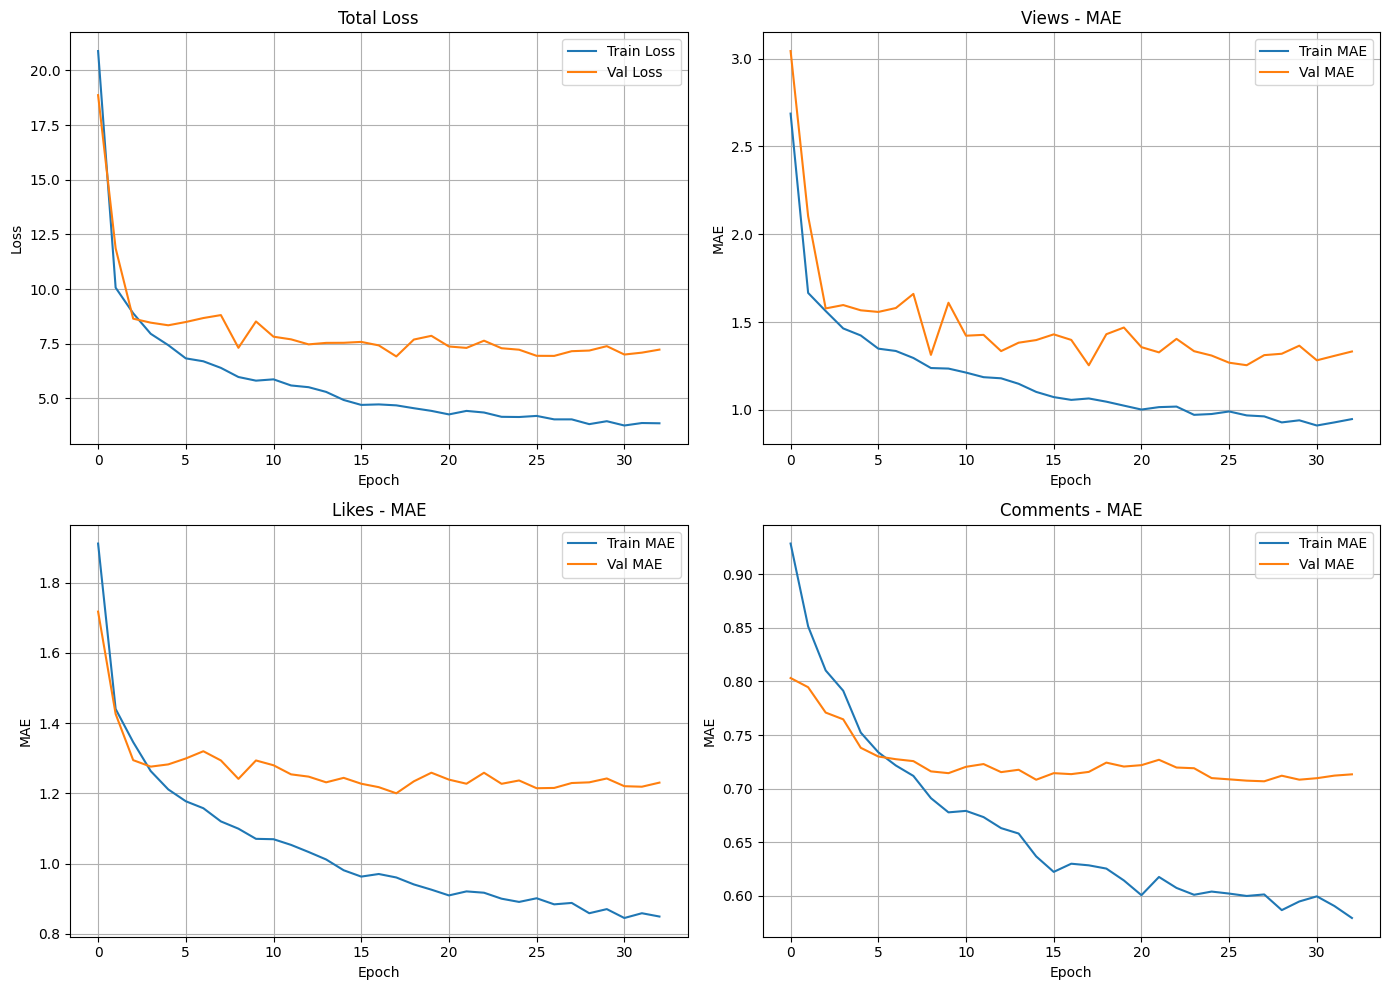

In [21]:
# Visualizar curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss total
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Views MAE
axes[0, 1].plot(history.history['views_mae'], label='Train MAE')
axes[0, 1].plot(history.history['val_views_mae'], label='Val MAE')
axes[0, 1].set_title('Views - MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Likes MAE
axes[1, 0].plot(history.history['likes_mae'], label='Train MAE')
axes[1, 0].plot(history.history['val_likes_mae'], label='Val MAE')
axes[1, 0].set_title('Likes - MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Comments MAE
axes[1, 1].plot(history.history['comments_mae'], label='Train MAE')
axes[1, 1].plot(history.history['val_comments_mae'], label='Val MAE')
axes[1, 1].set_title('Comments - MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

---
## 📊 7. Evaluación del Modelo

In [22]:
# Cargar mejor modelo
best_model = keras.models.load_model('best_model.keras')

# Predicciones en test set
predictions = best_model.predict(X_test_scaled)
pred_views = predictions[0].flatten()
pred_likes = predictions[1].flatten()
pred_comments = predictions[2].flatten()

# Des-transformar de log a escala original
pred_views_original = np.expm1(pred_views)
pred_likes_original = np.expm1(pred_likes)
pred_comments_original = np.expm1(pred_comments)

true_views_original = np.expm1(y_views_test)
true_likes_original = np.expm1(y_likes_test)
true_comments_original = np.expm1(y_comments_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [23]:
# Métricas en escala original
def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 para evitar división por 0
    
    print(f"\n📊 Métricas para {name}:")
    print(f"   MAE:  {mae:,.2f}")
    print(f"   RMSE: {rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

metrics_views = calculate_metrics(true_views_original, pred_views_original, "VIEWS")
metrics_likes = calculate_metrics(true_likes_original, pred_likes_original, "LIKES")
metrics_comments = calculate_metrics(true_comments_original, pred_comments_original, "COMMENTS")


📊 Métricas para VIEWS:
   MAE:  170,575.37
   RMSE: 1,955,032.24
   R²:   0.0004
   MAPE: 249.10%

📊 Métricas para LIKES:
   MAE:  1,384.82
   RMSE: 19,632.27
   R²:   0.0083
   MAPE: 234.04%

📊 Métricas para COMMENTS:
   MAE:  7.29
   RMSE: 69.94
   R²:   0.0279
   MAPE: 69.37%


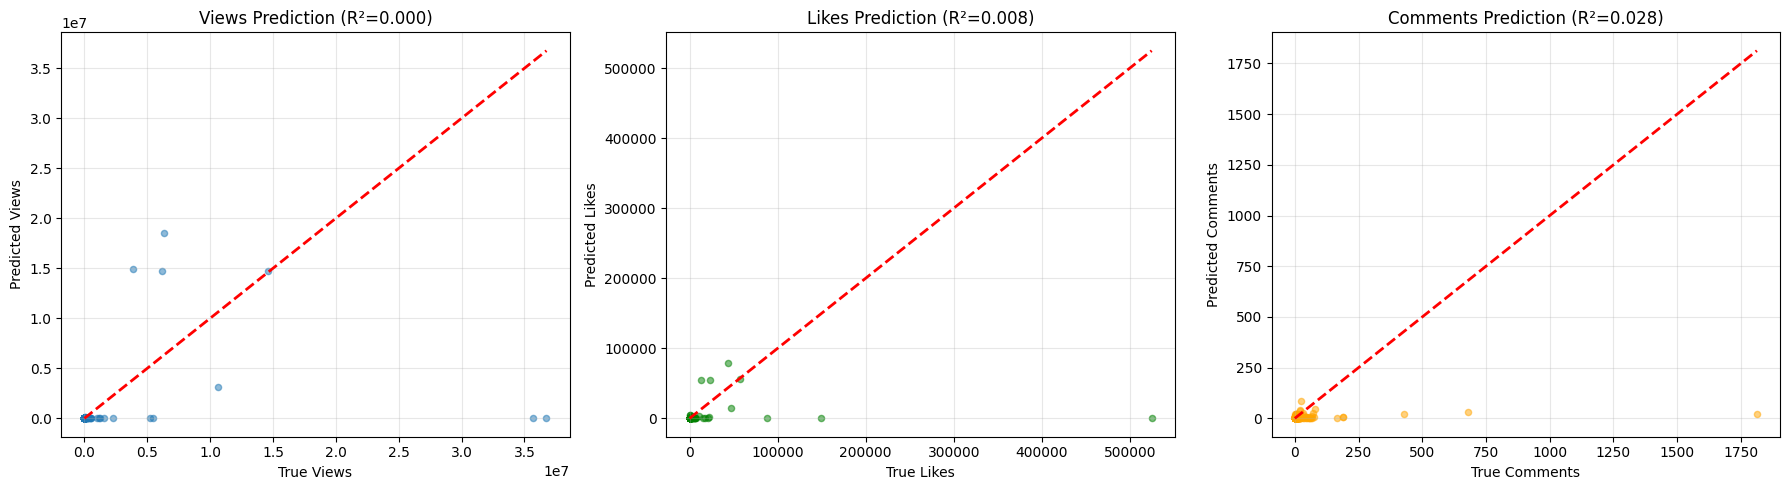

In [24]:
# Visualizar predicciones vs reales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Views
axes[0].scatter(true_views_original, pred_views_original, alpha=0.5, s=20)
axes[0].plot([0, true_views_original.max()], [0, true_views_original.max()], 'r--', lw=2)
axes[0].set_xlabel('True Views')
axes[0].set_ylabel('Predicted Views')
axes[0].set_title(f'Views Prediction (R²={metrics_views["r2"]:.3f})')
axes[0].grid(True, alpha=0.3)

# Likes
axes[1].scatter(true_likes_original, pred_likes_original, alpha=0.5, s=20, color='green')
axes[1].plot([0, true_likes_original.max()], [0, true_likes_original.max()], 'r--', lw=2)
axes[1].set_xlabel('True Likes')
axes[1].set_ylabel('Predicted Likes')
axes[1].set_title(f'Likes Prediction (R²={metrics_likes["r2"]:.3f})')
axes[1].grid(True, alpha=0.3)

# Comments
axes[2].scatter(true_comments_original, pred_comments_original, alpha=0.5, s=20, color='orange')
axes[2].plot([0, true_comments_original.max()], [0, true_comments_original.max()], 'r--', lw=2)
axes[2].set_xlabel('True Comments')
axes[2].set_ylabel('Predicted Comments')
axes[2].set_title(f'Comments Prediction (R²={metrics_comments["r2"]:.3f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🎯 8. Cálculo de Engagement Predicho

In [25]:
import pandas as pd

def calculate_engagement(views, likes, comments):
    """
    Engagement = (likes + 50*comments) / views * 100
    """
    # Evitar división por 0
    views = np.maximum(views, 1)
    engagement = ((likes + 50 * comments) / views) * 100
    return engagement

def classify_engagement_level(engagement):
    """
    Clasificar según los umbrales definidos
    """
    if engagement < 2:
        return 'Pasable 😐', 'orange'
    elif engagement <= 7:
        return 'Bueno 👍', 'lightgreen'
    elif engagement <= 10:
        return 'Muy Bueno 🔥', 'green'
    else:
        return 'Éxito Total 🚀', 'darkgreen'

# Calcular engagement predicho
predicted_engagement = calculate_engagement(pred_views_original, pred_likes_original, pred_comments_original)
true_engagement = calculate_engagement(true_views_original, true_likes_original, true_comments_original)

print("\n📊 Estadísticas de Engagement Predicho:")
# Usar pandas.Series para obtener estadísticas descriptivas

print(pd.Series(predicted_engagement).describe())


📊 Estadísticas de Engagement Predicho:
count    807.000000
mean       5.068203
std        3.662451
min        0.374493
25%        2.503826
50%        4.148433
75%        6.670414
max       28.175249
dtype: float64


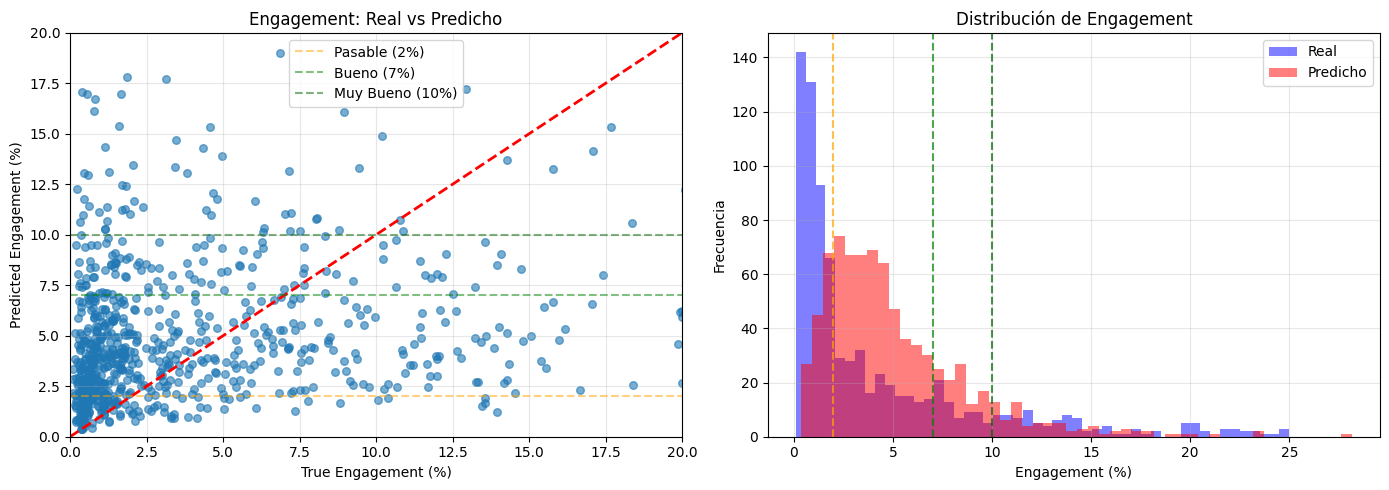

In [26]:
# Comparar engagement real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(true_engagement, predicted_engagement, alpha=0.6, s=30)
axes[0].plot([0, 20], [0, 20], 'r--', lw=2)
axes[0].axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Pasable (2%)')
axes[0].axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Bueno (7%)')
axes[0].axhline(y=10, color='darkgreen', linestyle='--', alpha=0.5, label='Muy Bueno (10%)')
axes[0].set_xlabel('True Engagement (%)')
axes[0].set_ylabel('Predicted Engagement (%)')
axes[0].set_title('Engagement: Real vs Predicho')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 20)

# Distribución
axes[1].hist(true_engagement, bins=50, alpha=0.5, label='Real', color='blue')
axes[1].hist(predicted_engagement, bins=50, alpha=0.5, label='Predicho', color='red')
axes[1].axvline(x=2, color='orange', linestyle='--', alpha=0.7)
axes[1].axvline(x=7, color='green', linestyle='--', alpha=0.7)
axes[1].axvline(x=10, color='darkgreen', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Engagement (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Engagement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


📊 Clasificación de Nivel de Engagement:

               precision    recall  f1-score   support

      Bueno 👍       0.26      0.60      0.36       210
  Muy Bueno 🔥       0.10      0.17      0.13        66
    Pasable 😐       0.72      0.22      0.34       424
Éxito Total 🚀       0.19      0.13      0.16       107

     accuracy                           0.30       807
    macro avg       0.32      0.28      0.25       807
 weighted avg       0.48      0.30      0.30       807



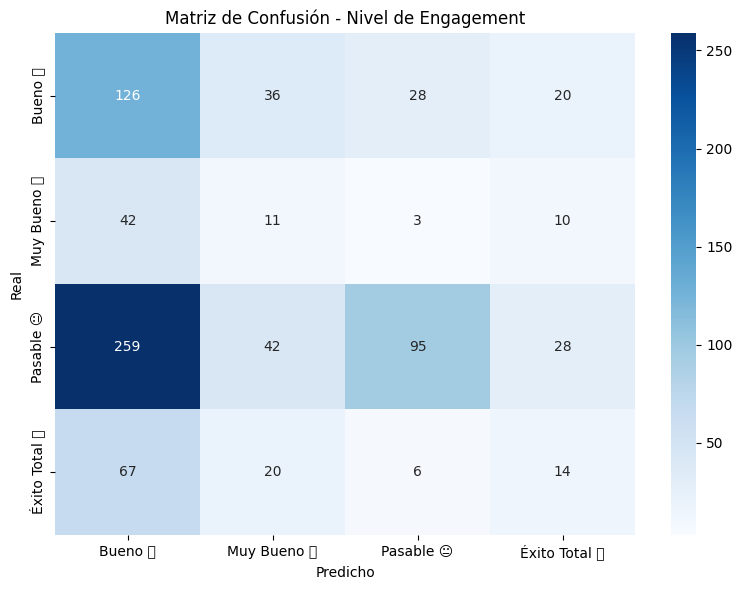

In [27]:
# Accuracy de clasificación de engagement
true_classes = [classify_engagement_level(e)[0] for e in true_engagement]
pred_classes = [classify_engagement_level(e)[0] for e in predicted_engagement]

from sklearn.metrics import classification_report, confusion_matrix

print("\n📊 Clasificación de Nivel de Engagement:\n")
print(classification_report(true_classes, pred_classes))

# Matriz de confusión
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(true_classes)), 
            yticklabels=sorted(set(true_classes)))
plt.title('Matriz de Confusión - Nivel de Engagement')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

---
## 🔮 9. Función de Predicción para Nuevos Videos

In [28]:
def predict_new_video(video_data, model, scaler, embeddings_model):
    """
    Predice views, likes, comments y engagement para un nuevo video.
    
    Args:
        video_data (dict): Diccionario con los metadatos del video
        model: Modelo de Keras entrenado
        scaler: StandardScaler entrenado
        embeddings_model: Modelo de embeddings
    
    Returns:
        dict: Predicciones con views, likes, comments y engagement
    """
    
    # Extraer features del video
    title = video_data.get('title', '')
    description = video_data.get('description', '')
    
    # Features textuales
    title_sentiment = get_sentiment(title)
    desc_sentiment = get_sentiment(description)
    
    title_length = len(title)
    title_word_count = len(title.split())
    title_emoji_count = count_emojis(title)
    title_hashtag_count = count_hashtags(title)
    title_uppercase_ratio = count_uppercase(title)
    
    desc_length = len(description)
    desc_word_count = len(description.split())
    desc_has_link = 1 if 'http' in description.lower() else 0
    
    # Features temporales
    publish_hour = video_data.get('publish_hour', 12)
    publish_day_of_week = video_data.get('publish_day_of_week', 0)
    publish_month = video_data.get('publish_month', 1)
    is_weekend = 1 if publish_day_of_week >= 5 else 0
    
    # Features de contenido
    tag_count = video_data.get('tag_count', 0)
    duration_sec = video_data.get('duration_sec', 30)
    category_id = video_data.get('category_id', 22)
    caption_bool = video_data.get('caption', 0)
    licensed_bool = video_data.get('licensed', 0)
    hd_bool = video_data.get('hd', 1)
    made_for_kids = video_data.get('made_for_kids', 0)
    
    # Features de canal
    subscriber_count = video_data.get('subscriber_count', 1000)
    log_subscribers = np.log1p(subscriber_count)
    
    # Embeddings
    title_embedding = embeddings_model.encode([title])[0]
    
    # Construir vector de features (mismo orden que en entrenamiento)
    numeric_features = np.array([
        title_length, title_word_count, title_emoji_count,
        title_hashtag_count, title_uppercase_ratio, title_sentiment,
        desc_length, desc_word_count, desc_has_link, desc_sentiment,
        publish_hour, publish_day_of_week, publish_month, is_weekend,
        tag_count,
        duration_sec, category_id, caption_bool, licensed_bool,
        hd_bool, made_for_kids,
        log_subscribers
    ])
    
    # Combinar con embeddings
    features = np.concatenate([numeric_features, title_embedding]).reshape(1, -1)
    
    # Escalar
    features_scaled = scaler.transform(features)
    
    # Predecir
    predictions = model.predict(features_scaled, verbose=0)
    
    # Des-transformar de log
    pred_views = np.expm1(predictions[0][0][0])
    pred_likes = np.expm1(predictions[1][0][0])
    pred_comments = np.expm1(predictions[2][0][0])
    
    # Calcular engagement
    engagement = calculate_engagement(pred_views, pred_likes, pred_comments)
    engagement_level, engagement_color = classify_engagement_level(engagement)
    
    # Resultados
    results = {
        'predicted_views': int(pred_views),
        'predicted_likes': int(pred_likes),
        'predicted_comments': int(pred_comments),
        'predicted_engagement': round(engagement, 2),
        'engagement_level': engagement_level,
        'engagement_color': engagement_color
    }
    
    return results

print("✅ Función de predicción lista")

✅ Función de predicción lista


### Ejemplo de uso

In [29]:
# Ejemplo de video nuevo
nuevo_video = {
    'title': '🔥 Amazing Chicken Recipe You MUST Try! #foodie #viral',
    'description': 'Check out this incredible recipe that will blow your mind! Don\'t forget to subscribe!',
    'publish_hour': 18,  # 6 PM
    'publish_day_of_week': 4,  # Viernes
    'publish_month': 1,
    'tag_count': 5,
    'duration_sec': 45,
    'category_id': 22,  # People & Blogs
    'caption': 1,
    'licensed': 0,
    'hd': 1,
    'made_for_kids': 0,
    'subscriber_count': 5000
}

# Predecir
resultado = predict_new_video(
    nuevo_video, 
    best_model, 
    scaler, 
    model_embeddings
)

# Mostrar resultados
print("\n" + "="*60)
print("🎬 PREDICCIÓN PARA NUEVO VIDEO")
print("="*60)
print(f"\n📹 Título: {nuevo_video['title']}")
print(f"\n📊 PREDICCIONES:")
print(f"   👁️  Views:    {resultado['predicted_views']:,}")
print(f"   👍 Likes:    {resultado['predicted_likes']:,}")
print(f"   💬 Comments: {resultado['predicted_comments']:,}")
print(f"\n🎯 ENGAGEMENT: {resultado['predicted_engagement']:.2f}%")
print(f"   Nivel: {resultado['engagement_level']}")
print("="*60)


🎬 PREDICCIÓN PARA NUEVO VIDEO

📹 Título: 🔥 Amazing Chicken Recipe You MUST Try! #foodie #viral

📊 PREDICCIONES:
   👁️  Views:    3,597
   👍 Likes:    133
   💬 Comments: 4

🎯 ENGAGEMENT: 9.47%
   Nivel: Muy Bueno 🔥


---
## 💾 10. Guardar Artefactos del Modelo

In [30]:
# Guardar modelo final
best_model.save('youtube_predictor_final.keras')
print("✅ Modelo guardado: youtube_predictor_final.keras")

# Guardar scaler (ya se guardó antes)
print("✅ Scaler guardado: scaler.pkl")

# Guardar embeddings model name (para reconstruirlo)
with open('model_config.txt', 'w') as f:
    f.write("embeddings_model: all-MiniLM-L6-v2\n")
    f.write(f"features_count: {len(features_to_use)}\n")
    f.write(f"feature_names: {','.join(features_to_use)}\n")
print("✅ Configuración guardada: model_config.txt")

# Guardar métricas de evaluación
import json
metrics_summary = {
    'views': metrics_views,
    'likes': metrics_likes,
    'comments': metrics_comments,
    'test_samples': len(X_test)
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=4)
print("✅ Métricas guardadas: model_metrics.json")

print("\n🎉 ¡Modelo completo guardado y listo para producción!")

✅ Modelo guardado: youtube_predictor_final.keras
✅ Scaler guardado: scaler.pkl
✅ Configuración guardada: model_config.txt
✅ Métricas guardadas: model_metrics.json

🎉 ¡Modelo completo guardado y listo para producción!


---
## 📝 11. Resumen Final y Recomendaciones

In [31]:
print("""\n
╔════════════════════════════════════════════════════════════════╗
║                    RESUMEN DEL PROYECTO                        ║
╚════════════════════════════════════════════════════════════════╝

✅ MODELO ENTRENADO EXITOSAMENTE

📊 Arquitectura:
   - Multi-Output Neural Network (3 outputs)
   - Inputs: Features numéricas + Embeddings de título
   - Outputs: Views, Likes, Comments

🎯 Métricas de Rendimiento:
   - Views R²:    {:.3f}
   - Likes R²:    {:.3f}
   - Comments R²: {:.3f}

💡 Interpretación de Engagement:
   - < 2%:   Pasable 😐
   - 3-7%:   Bueno 👍
   - 7-10%:  Muy Bueno 🔥
   - > 10%:  Éxito Total 🚀

📁 Archivos Guardados:
   ✓ youtube_predictor_final.keras  (Modelo)
   ✓ scaler.pkl                     (Normalizador)
   ✓ title_embeddings.npy           (Embeddings)
   ✓ model_config.txt               (Configuración)
   ✓ model_metrics.json             (Métricas)

🚀 Próximos Pasos:
   1. Usar predict_new_video() para nuevas predicciones
   2. Recopilar más datos para mejorar el modelo
   3. Experimentar con diferentes arquitecturas
   4. Añadir más features (análisis de thumbnails, etc.)
   5. Crear API REST para integración

╔════════════════════════════════════════════════════════════════╗
║                  ¡PROYECTO COMPLETADO! 🎉                      ║
╚════════════════════════════════════════════════════════════════╝
""".format(
    metrics_views['r2'],
    metrics_likes['r2'],
    metrics_comments['r2']
))



╔════════════════════════════════════════════════════════════════╗
║                    RESUMEN DEL PROYECTO                        ║
╚════════════════════════════════════════════════════════════════╝

✅ MODELO ENTRENADO EXITOSAMENTE

📊 Arquitectura:
   - Multi-Output Neural Network (3 outputs)
   - Inputs: Features numéricas + Embeddings de título
   - Outputs: Views, Likes, Comments

🎯 Métricas de Rendimiento:
   - Views R²:    0.000
   - Likes R²:    0.008
   - Comments R²: 0.028

💡 Interpretación de Engagement:
   - < 2%:   Pasable 😐
   - 3-7%:   Bueno 👍
   - 7-10%:  Muy Bueno 🔥
   - > 10%:  Éxito Total 🚀

📁 Archivos Guardados:
   ✓ youtube_predictor_final.keras  (Modelo)
   ✓ scaler.pkl                     (Normalizador)
   ✓ title_embeddings.npy           (Embeddings)
   ✓ model_config.txt               (Configuración)
   ✓ model_metrics.json             (Métricas)

🚀 Próximos Pasos:
   1. Usar predict_new_video() para nuevas predicciones
   2. Recopilar más datos para mejorar 